# **Notebook 2 - Customer Segmentation** 

Afonso Fernandes 20241710, Lourenço Lima 20241711, Lucas Casimiro 20241796

## Imports

In [319]:
import os
import sys
import warnings
from pathlib import Path

def _find_project_root(start, marker="requirements.txt"):
    path = Path(start).resolve()
    for candidate in [path] + list(path.parents):
        if (candidate / marker).exists():
            return str(candidate)
    raise RuntimeError(f"Could not find project root (marker={marker!r}, searched from {start})")

PROJECT_ROOT = _find_project_root(os.path.abspath("."))
os.chdir(PROJECT_ROOT)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [420]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors
import seaborn as sns
import plotly.express as px
from pylab import rcParams
rcParams['figure.figsize'] = 30, 15
import umap

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import confusion_matrix
from scipy.cluster.hierarchy import dendrogram, linkage
from functions.preprocessing import scale_features, FEATURE_COLS, snap_coordinates_to_land
from functions.clustering import *

import warnings
warnings.filterwarnings('ignore', category = FutureWarning)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## **1. Scaling**

Before proceeding, we will save 3 scaled datasets using 3 different scalers, to see which one gives the better results.

In [437]:
clean_data = pd.read_csv('data/ci_clustering.csv')
clean_data

,customer_id,customer_name,customer_gender,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,...,share_electronics,share_vegetables,share_nonalcohol_drinks,share_alcohol_drinks,share_meat,share_fish,share_hygiene,share_videogames,share_petfood,dietary_preference
0,3,Bsc. Crystal Kitchens,female,1.0,1.0,1.0,3.0,11731.0,4553.0,12.0,...,0.244917,0.020065,0.017375,0.009521,0.001506,0.011458,0.029693,0.013771,0.020656,omnivore
1,4,Bsc. Glenda Bauman,female,1.0,0.0,0.0,2.0,13694.0,963.0,12.0,...,0.047596,0.099442,0.026343,0.004695,0.002125,0.000741,0.092918,0.016458,0.032867,omnivore
2,5,Msc. Antonio Campbell,male,0.0,0.0,0.0,2.0,12407.0,0.0,11.0,...,0.000000,0.035694,0.006496,0.007589,0.081356,0.017557,0.032607,0.006496,0.014277,omnivore
3,7,John Kelling,male,0.0,0.0,2.0,1.0,7493.0,1105.0,18.0,...,0.073903,0.005618,0.050629,0.075776,0.065008,0.072432,0.032437,0.110754,0.012306,omnivore
4,8,Arthur Dematteo,male,0.0,0.0,3.0,1.0,9187.0,10841.0,17.0,...,0.420243,0.014730,0.022948,0.027833,0.041400,0.039346,0.011513,0.048765,0.017095,omnivore
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32566,39996,Joshua Howard,male,0.0,0.0,2.0,1.0,475.0,13488.0,12.0,...,0.677108,0.009538,0.028765,0.049900,0.051205,0.057932,0.003112,0.080221,0.018373,omnivore
32567,39997,Anthony Hines,male,1.0,0.0,1.0,1.0,8430.0,14408.0,21.0,...,0.488076,0.009858,0.016836,0.048001,0.044817,0.020393,0.007453,0.071308,0.007690,omnivore
32568,39998,Edna Hasselman,female,1.0,1.0,0.0,4.0,8029.0,1480.0,14.0,...,0.105017,0.113532,0.035053,0.008302,0.021784,0.000000,0.121975,0.006315,0.018307,omnivore
32569,39999,George Kramer,male,1.0,1.0,1.0,6.0,8364.0,3114.0,11.0,...,0.225881,0.043232,0.021979,0.047947,0.000000,0.008197,0.029740,0.000000,0.016321,omnivore


In [353]:
# Standard Scaler
clean_std = scale_features(clean_data.copy(), StandardScaler)

# Robust Scaler
clean_rb = scale_features(clean_data.copy(), RobustScaler)

# MinMax Scaler
clean_minmax = scale_features(clean_data.copy(), MinMaxScaler)

## **2. Clustering**

The cluster analysis in the notebook is separated by scalers, and in each section 2 algorithms will be tested: `K-means` and `Hierarchical (Ward linkage)`. 

For each scaler section, 3 tasks are developed:
 - **Mathematical Comparison**: silhouette scores (a common analysis between both models) is used as a comparison between algorithms and plotted for each amount of clusters.
 - **Visual Inspection**: an elbow method is plotted to decide an amount for k in K-means, and a dendrogram is plotted to decide the amount of clusters created by Hierarchical Ward algorithm.
 - **Cluster Analysis**: collect insights based on the clusters created from both algorithms (profiling).
  
We specifically use the *Ward* linkage for our hierarchical model because it minimizes within-cluster variance (the exact same mathematical objective as K-Means). Below is proof of this linkage method superiority.

**NOTE**: in most cases, just following mathematical and visual proof will end up in under segmentation. In some cases, the choice for number of clusters is higher than the logical choice, as better results were obtained (more profiles, and more precise personas, backed by the data). Often, there's clear possibility of clusters representing more than 1 profile.

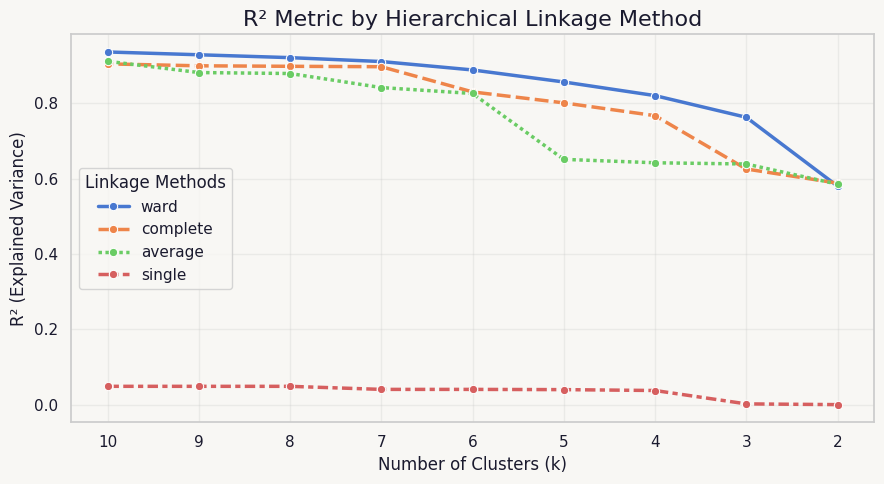

In [ ]:
plot_r2_hc(clean_data, FEATURE_COLS)

## **Standard Scaler**

### Mathematical Comparison

In [354]:
results_std = compare_clustering_models(clean_std, FEATURE_COLS)
results_std

,model,k,silhouette
0,kmeans,4,0.143203
1,kmeans,3,0.141029
2,kmeans,10,0.134990
3,kmeans,6,0.133227
4,kmeans,5,0.130419
5,kmeans,9,0.130050
6,kmeans,8,0.129891
7,hierarchical_ward,4,0.126948
8,hierarchical_ward,3,0.126088
9,kmeans,7,0.121285


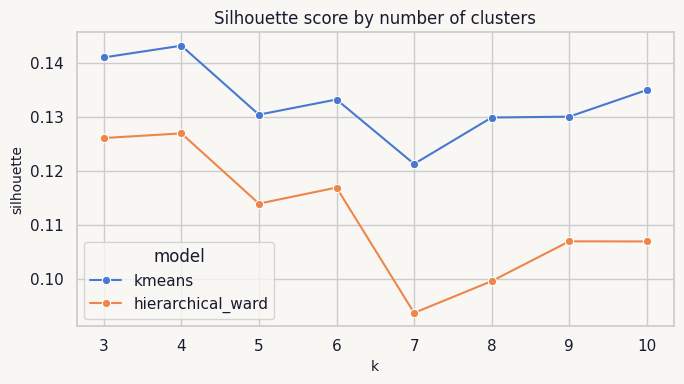

In [355]:
plot_metric_comparison(results_std)

### Visual Inspection

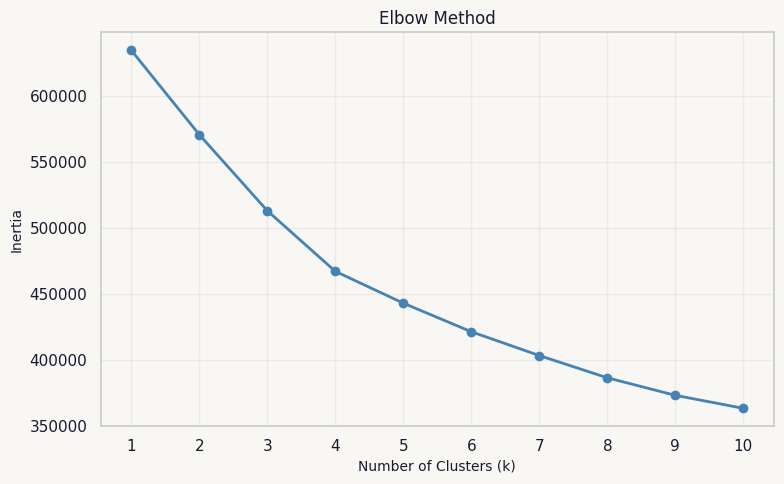

,k,inertia
0,1,634788.700347
1,2,570809.335224
2,3,513085.981207
3,4,467084.855219
4,5,442951.680766
5,6,421264.604303
6,7,403194.759556
7,8,386329.694191
8,9,373028.165807
9,10,363162.381194


In [356]:
compare_kmeans_inertia(clean_std, FEATURE_COLS)

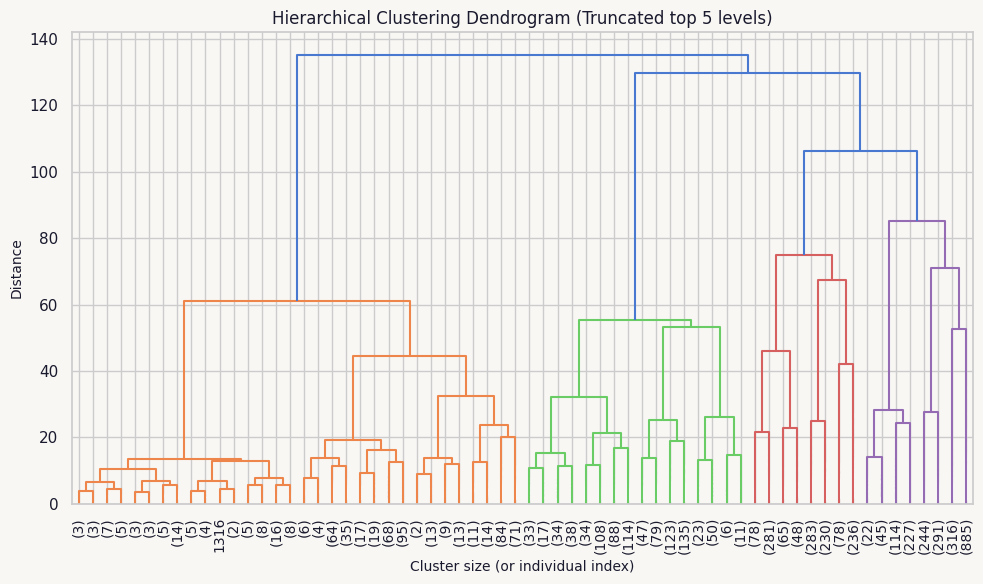

In [357]:
plot_dendrogram(clean_std, FEATURE_COLS)

### Cluster Analysis


 - KMeans (k=4): The Silhouette Score for Standard Scaler hits a global maximum at k=4. Furthermore, the elbow curve shows a significant flattening of inertia after 4 clusters.
 - Hierarchical Ward (k=6): The Silhouette score for Ward linkage hits a local peak at k=6, dropping significantly if we force a split to k=7. As for the dendrogram, it splits into 4 major trees, but we cut a little lower at around ~70 distance, to obtain the most justified clusters before the tree started shattering.

In [358]:
optimal_k_kmeans_std = 4
optimal_k_ward_std = 6

In [ ]:
kmeans_labels_std, kmeans_model_std = fit_final_kmeans(clean_std, FEATURE_COLS, n_clusters=optimal_k_kmeans_std)
final_std_k = add_clusters(clean_data, kmeans_labels_std, cluster_col='std_kmeans4')

calculate_group_means(final_std_k, cluster_col='std_kmeans4')

std_kmeans6,0,1,2,3
customer_id,20218.946063,19732.000144,19388.119947,20676.643154
kids_home,0.273732,1.016301,1.550506,0.984588
teens_home,0.309331,0.865695,1.356759,0.612519
number_complaints,0.972762,0.663156,0.830295,1.133132
distinct_stores_visited,1.585491,3.383872,3.312814,3.390223
lifetime_spend_groceries,8145.585761,10934.158540,27848.030383,10952.304936
lifetime_spend_electronics,8964.023732,1397.812031,3102.391898,1025.015034
typical_hour,17.566073,12.384016,11.337737,12.455654
lifetime_spend_vegetables,179.665588,1705.660271,576.130603,401.982980
lifetime_spend_nonalcohol_drinks,532.792880,515.432920,587.871158,276.734399


 - Cluster 0: Tech enthusiasts (0.37 share_electronics), on the younger side, with the fewest tenure and loyalty card percentage. Latest typical shopping hours. - clearly possibility of being split into more profiles
 - Cluster 1: Vegans (0.11 share_vegetables with remarkably low meat and fish shares)
 - Cluster 2: Loyal core spenders (oldest on average with most money spent)
 - Cluster 3: Karens (more complaints and bargain hunters)

In [361]:
ward_labels_std, ward_model_std = fit_final_hierarchical(clean_std, FEATURE_COLS, n_clusters=optimal_k_ward_std)
final_std_ward = add_clusters(clean_data, ward_labels_std, cluster_col='std_ward6')

calculate_group_means(final_std_ward, cluster_col='std_ward6')

std_ward6,0,1,2,3,4,5
customer_id,20151.547076,19937.933884,19843.051025,19926.994015,19529.522538,20199.594699
kids_home,0.814931,0.700092,1.030052,0.283457,3.366945,1.816557
teens_home,0.782796,0.624793,0.877759,0.307876,2.707846,0.784991
number_complaints,0.674635,0.806428,0.626076,0.906392,0.839065,2.394282
distinct_stores_visited,3.438229,4.033609,3.364220,1.690687,3.163606,2.298987
lifetime_spend_groceries,25160.769668,9553.754454,11289.825481,8851.760594,24924.504841,13536.575640
lifetime_spend_electronics,2108.512883,1015.204224,1422.292064,8123.458942,4888.853422,1276.428231
typical_hour,11.681395,13.751882,12.437627,17.359349,10.113856,10.445503
lifetime_spend_vegetables,507.671304,458.377043,1743.099703,233.608810,793.169616,332.792436
lifetime_spend_nonalcohol_drinks,465.779955,305.179431,511.856472,501.056021,810.636394,281.018761


 - Cluster 0: Loyal cores spenders
 - Cluster 1: Bargain hunters
 - Cluster 2: Vegans
 - Cluster 3: Tech enthusiasts
 - Cluster 4: Big family (big spenders)
 - Cluster 5: Karens (most complaints, youngest by a lot)

## **Robust Scaler**

### Mathematical Comparison

In [363]:
results_rb = compare_clustering_models(clean_rb, FEATURE_COLS)
results_rb

,model,k,silhouette
0,hierarchical_ward,3,0.283446
1,kmeans,3,0.281911
2,kmeans,4,0.208917
3,hierarchical_ward,4,0.188719
4,hierarchical_ward,5,0.183718
5,kmeans,5,0.151106
6,hierarchical_ward,6,0.150950
7,kmeans,7,0.150080
8,kmeans,9,0.149240
9,kmeans,6,0.145697


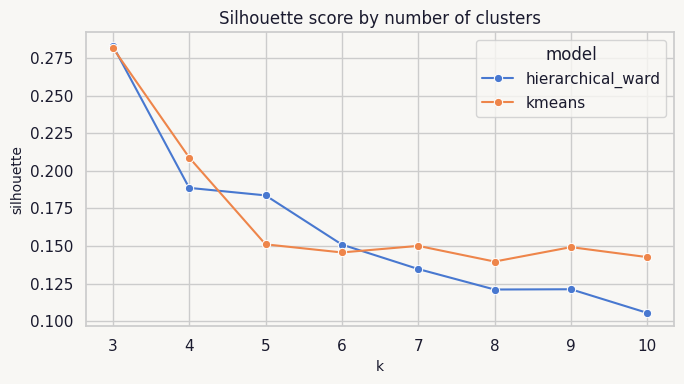

In [364]:
plot_metric_comparison(results_rb)

### Visual Inspection

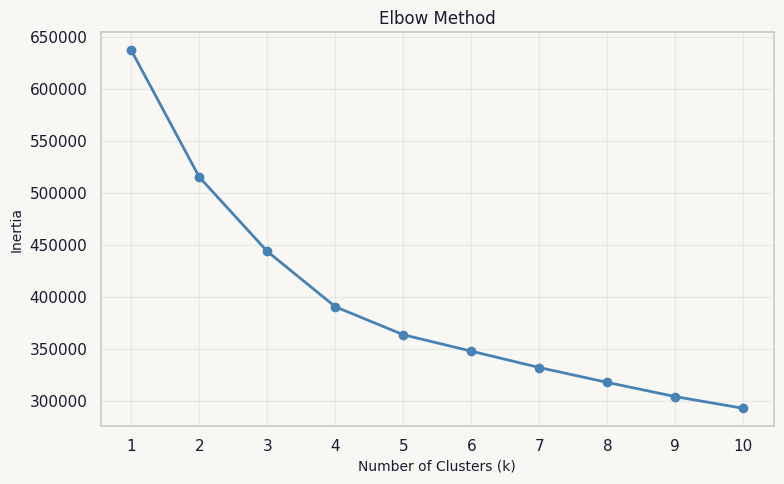

,k,inertia
0,1,637001.898435
1,2,515018.647241
2,3,443542.410237
3,4,390282.548520
4,5,363328.116788
5,6,347543.437001
6,7,331788.207704
7,8,317472.633147
8,9,303812.991798
9,10,292536.887934


In [365]:
compare_kmeans_inertia(clean_rb, FEATURE_COLS)

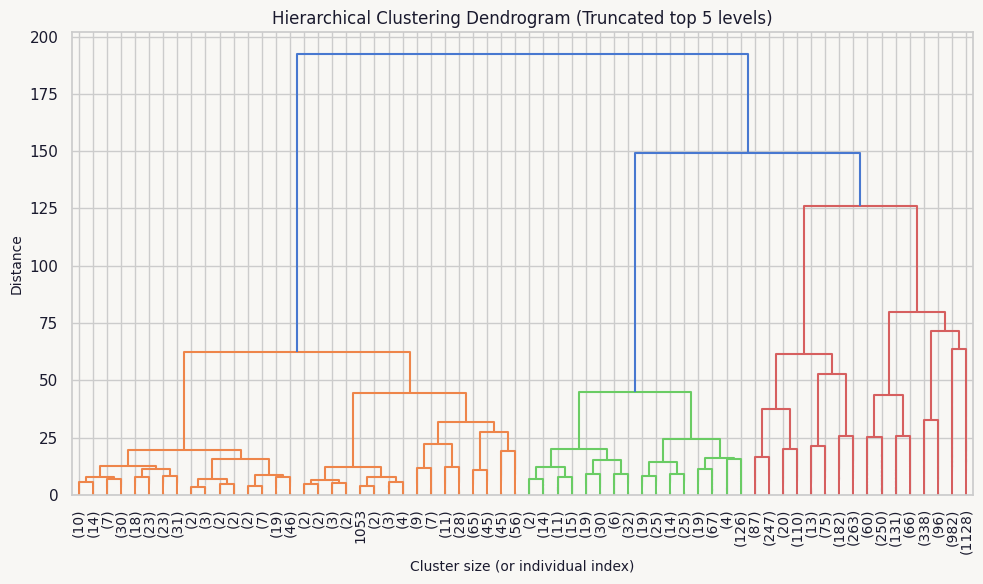

In [366]:
plot_dendrogram(clean_rb, FEATURE_COLS)

### Cluster Analysis

 - KMeans (k=5): evaluating the Elbow Method, the curve shows a distinct inflection point at k = 5. The silhouette scores plot show a significant drop from 5 to 6 as well. 
 - Hierarchical Ward (k=7): the silhouette scores stabilizes after k=5, meaning between 5 and 10 clusters, there's no big change in the score. As for the dendrogram, while higher level cuts (4 or 5) could be justified, we found through trial and error that they left critical customer behaviors grouped together, hence the increase until 7, where we found 7 defined personas.

In [405]:
optimal_k_kmeans_rb = 5
optimal_k_ward_rb = 7

In [ ]:
kmeans_labels_rb, kmeans_model_rb = fit_final_kmeans(clean_rb, FEATURE_COLS, n_clusters=optimal_k_kmeans_rb)
final_rb_kmeans = add_clusters(clean_data, kmeans_labels_rb, cluster_col='rb_kmeans5')

calculate_group_means(final_rb_kmeans, cluster_col='rb_kmeans5') 

rb_kmeans6,0,1,2,3,4
customer_id,20067.547619,19839.145682,19723.546170,20353.037643,19728.172593
kids_home,0.313492,1.025321,3.629921,0.962862,0.886892
teens_home,0.339002,0.873222,2.916965,0.581492,0.840647
number_complaints,1.050454,0.650884,0.972799,1.122515,0.786457
distinct_stores_visited,1.666950,3.403052,3.191124,3.292360,3.382353
lifetime_spend_groceries,8368.967120,9751.704648,24668.217967,9987.749622,26896.134292
lifetime_spend_electronics,8861.750567,1323.994450,4799.351467,1169.653245,2373.610932
typical_hour,16.890873,12.276795,10.213314,12.697043,11.984301
lifetime_spend_vegetables,241.357710,1717.967915,791.263422,383.865678,615.788160
lifetime_spend_nonalcohol_drinks,533.950964,525.144641,802.170365,291.778787,482.914129


 - Cluster 0: Tech enthusiasts (late shoppers)
 - Cluster 1: Vegans
 - Cluster 2: Big family (big spenders)
 - Cluster 3: Karens 
 - Cluster 4: Loyal core spenders (few dependants)

In [407]:
ward_labels_rb, ward_model_rb = fit_final_hierarchical(clean_rb, FEATURE_COLS, n_clusters=optimal_k_ward_rb)
final_rb_ward = add_clusters(clean_data, ward_labels_rb, cluster_col='rb_ward7')

calculate_group_means(final_rb_ward, cluster_col='rb_ward7')

rb_ward7,0,1,2,3,4,5,6
customer_id,19803.104581,19838.093917,19770.204130,20435.415224,20459.767101,20231.804675,19580.728146
kids_home,1.031646,0.928054,3.958236,0.594843,0.333876,1.834454,0.237986
teens_home,0.879747,0.869895,3.098545,0.528259,0.380293,0.763689,0.298398
number_complaints,0.632761,0.734103,0.852651,0.721300,0.999186,2.371438,1.081465
distinct_stores_visited,3.371459,3.452352,3.233224,3.767043,1.675896,2.224143,1.438902
lifetime_spend_groceries,11401.635925,24693.805532,23982.318160,9938.651713,6979.746743,12840.162024,9033.362471
lifetime_spend_electronics,1424.657926,2368.521024,4897.773815,950.234369,5043.122150,1116.560359,12153.781236
typical_hour,12.427969,11.688265,10.176443,14.215825,16.820033,10.428754,17.357437
lifetime_spend_vegetables,1752.207354,487.767362,805.615673,464.091840,246.874593,306.733589,178.009153
lifetime_spend_nonalcohol_drinks,509.632761,510.044115,816.174097,258.347404,524.157166,256.077810,550.881465


 - Cluster 0: Vegans
 - Cluster 1: Loyal core spenders
 - Cluster 2: Big family (big spenders)
 - Cluster 3: Bargain hunters
 - Cluster 4: Gamers (tech enthusiasts, with almost a 10% share of money spent on videogames)
 - Cluster 5: Karens
 - Cluster 6: Tech enthusiasts

## **MinMax Scaler**

### Mathematical Comparison

In [372]:
results_minmax = compare_clustering_models(clean_minmax, FEATURE_COLS)
results_minmax

,model,k,silhouette
0,kmeans,4,0.268377
1,hierarchical_ward,4,0.254121
2,kmeans,5,0.237077
3,hierarchical_ward,3,0.236763
4,kmeans,3,0.236763
5,kmeans,6,0.222441
6,hierarchical_ward,5,0.214619
7,hierarchical_ward,7,0.203800
8,kmeans,7,0.195407
9,hierarchical_ward,6,0.190449


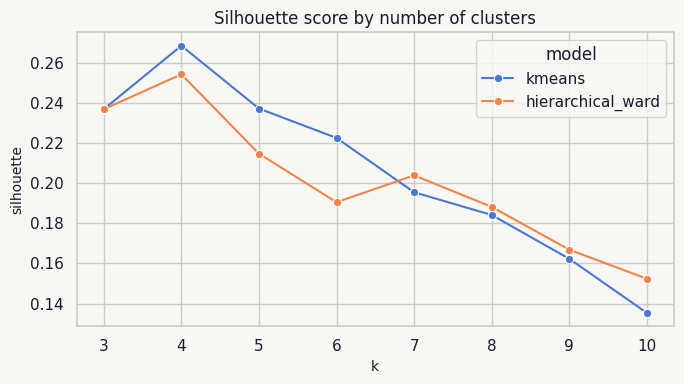

In [375]:
plot_metric_comparison(results_minmax)

### Visual Inspection

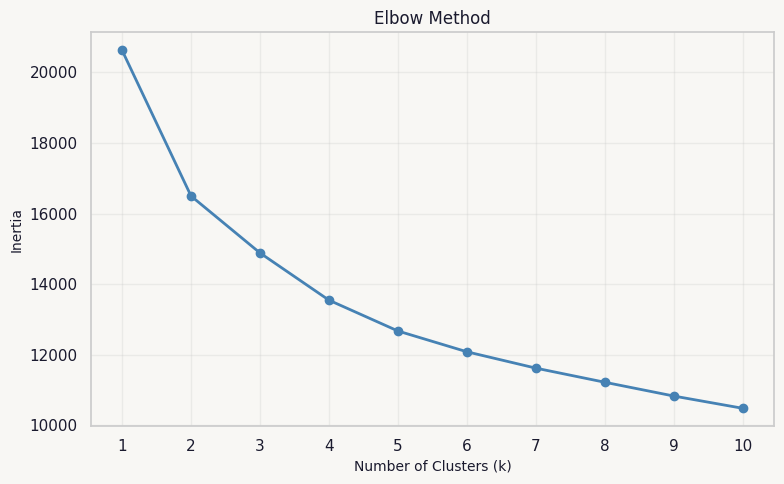

,k,inertia
0,1,20626.629272
1,2,16495.612768
2,3,14881.636874
3,4,13543.154722
4,5,12669.623729
5,6,12080.517143
6,7,11617.095469
7,8,11216.787466
8,9,10826.157640
9,10,10478.482272


In [376]:
compare_kmeans_inertia(clean_minmax, FEATURE_COLS)

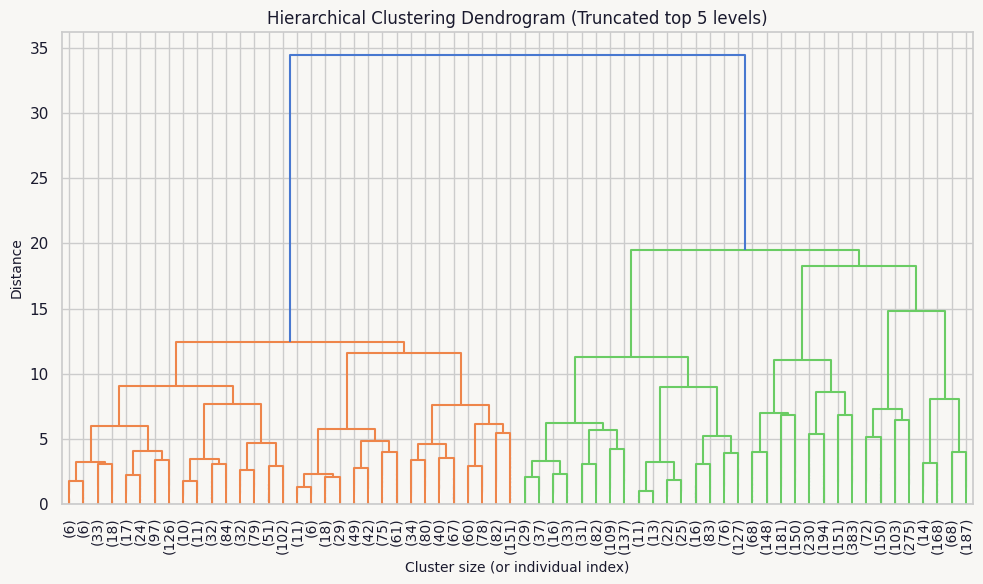

In [377]:
plot_dendrogram(clean_minmax, FEATURE_COLS)

### Cluster Analysis

 - KMeans (k=6): the curve for the MinMax scaler smooths out considerably after k=6. It could be 5, but we prioritized exploration (7 fell too much on the silhouette scores plot).
 - Hierarchical Ward (k=7): the silhouette score shows a local optima at k=7. Furthermore, we cut the dendrogram at a distance that splits a dense sub-group to extract a crucial niche profile, safely avoiding the rapid fragmentation zone that occurs just below distance ~11.5.

In [ ]:
optimal_k_kmeans_minmax = 6
optimal_k_ward_minmax = 7

In [ ]:
kmeans_labels_minmax, kmeans_model_minmax = fit_final_kmeans(clean_minmax, FEATURE_COLS, n_clusters=optimal_k_kmeans_minmax)
final_minmax_kmeans = add_clusters(clean_data, kmeans_labels_minmax, cluster_col='minmax_kmeans6')

calculate_group_means(final_minmax_kmeans, cluster_col='minmax_kmeans6')

minmax_kmeans,0,1,2,3,4,5
customer_id,11176.435974,11867.662754,24608.592093,22635.798767,24035.146330,22185.012207
kids_home,1.147802,1.239952,1.306476,0.889242,1.377979,0.410244
teens_home,0.981737,1.078989,1.149557,0.568105,0.941373,0.424126
number_complaints,0.772351,0.780740,0.848534,1.044144,1.033524,0.975347
distinct_stores_visited,3.422383,3.314365,3.306067,3.845695,2.826343,2.071565
lifetime_spend_groceries,18034.813761,18720.602268,19336.701431,14758.183933,15783.107086,10444.520823
lifetime_spend_electronics,2104.709705,2183.458416,2507.408998,1231.893816,2106.673022,7243.866204
typical_hour,12.189849,11.761043,10.905521,13.925234,9.993168,19.631403
lifetime_spend_vegetables,880.285836,942.496021,843.985276,384.500696,739.790753,387.839157
lifetime_spend_nonalcohol_drinks,499.414525,522.052328,527.728153,285.821038,437.680330,505.500000


 - Cluster 0: 
 - Cluster 1: 
 - Cluster 2:
 - Cluster 3:
 - Cluster 4:
 - Cluster 5:

In [ ]:
ward_labels_minmax, ward_model_minmax = fit_final_hierarchical(clean_minmax, FEATURE_COLS, n_clusters=optimal_k_ward_minmax)
final_minmax_ward = add_clusters(clean_data, ward_labels_minmax, cluster_col='minmax_ward7')

calculate_group_means(final_minmax_ward, cluster_col='minmax_ward7')

minmax_ward,0,1,2,3,4,5,6
customer_id,12167.042309,23634.504870,23437.652069,20109.125717,26350.382147,9048.437923,22194.473208
kids_home,1.247363,1.102355,0.690254,0.223178,1.338623,0.906546,1.873962
teens_home,1.099687,0.729414,0.600000,0.308354,1.189848,0.673138,0.556981
number_complaints,0.740582,0.919072,0.833378,1.074939,0.881564,0.952596,1.981887
distinct_stores_visited,3.179321,3.302993,4.248598,1.422604,2.951225,4.130474,2.190189
lifetime_spend_groceries,17484.710212,15809.783602,14939.036315,8082.056511,18791.174912,21447.272686,10337.952453
lifetime_spend_electronics,2039.730845,1845.217815,1262.885981,10151.617117,2998.139323,2028.519639,960.578868
typical_hour,11.305784,13.621215,13.878772,19.460688,10.940723,14.050113,9.521509
lifetime_spend_vegetables,1067.432479,784.348149,453.280374,159.979934,743.465928,398.120542,229.186415
lifetime_spend_nonalcohol_drinks,522.734322,431.092261,284.907877,560.107699,525.823804,435.621219,226.880000


 - Cluster 0: 
 - Cluster 1:
 - Cluster 2:
 - Cluster 3:
 - Cluster 4:
 - Cluster 5:

# **3. Final Clustering Solution**

The best profiles were obtained by using Robust scaler, with 7 clusters using Hierarchical Clustering (Ward Linkage).

In [427]:
calculate_group_means(final_rb_ward, cluster_col='rb_ward7')

rb_ward7,0,1,2,3,4,5,6
customer_id,19803.104581,19838.093917,19770.204130,20435.415224,20459.767101,20231.804675,19580.728146
kids_home,1.031646,0.928054,3.958236,0.594843,0.333876,1.834454,0.237986
teens_home,0.879747,0.869895,3.098545,0.528259,0.380293,0.763689,0.298398
number_complaints,0.632761,0.734103,0.852651,0.721300,0.999186,2.371438,1.081465
distinct_stores_visited,3.371459,3.452352,3.233224,3.767043,1.675896,2.224143,1.438902
lifetime_spend_groceries,11401.635925,24693.805532,23982.318160,9938.651713,6979.746743,12840.162024,9033.362471
lifetime_spend_electronics,1424.657926,2368.521024,4897.773815,950.234369,5043.122150,1116.560359,12153.781236
typical_hour,12.427969,11.688265,10.176443,14.215825,16.820033,10.428754,17.357437
lifetime_spend_vegetables,1752.207354,487.767362,805.615673,464.091840,246.874593,306.733589,178.009153
lifetime_spend_nonalcohol_drinks,509.632761,510.044115,816.174097,258.347404,524.157166,256.077810,550.881465


In [ ]:
# Mapping each cluster to its corresponding label
clusters_mapping = {
    0: 'Vegans',
    1: 'Loyal core spenders',
    2: 'Big families (big spenders)',
    3: 'Bargain hunters',
    4: 'Gamers',
    5: 'Karens',
    6: 'Tech enthusiasts'}

In [ ]:
# Creating new columns with corresponding cluster for each customer
clean_data['final_cluster_nr'] = final_rb_ward['rb_ward7']
clean_data['final_cluster_label'] = [clusters_mapping[i] for i in clean_data['final_cluster_nr']]


final_cluster_label
Loyal core spenders            11606
Vegans                          6636
Bargain hunters                 5662
Karens                          3123
Tech enthusiasts                2185
Big families (big spenders)     2131
Gamers                          1228
Name: count, dtype: int64

In [ ]:
#Checking the counts for each cluster
clean_data['final_cluster_label'].value_counts()

final_cluster_label
Loyal core spenders            11606
Vegans                          6636
Bargain hunters                 5662
Karens                          3123
Tech enthusiasts                2185
Big families (big spenders)     2131
Gamers                          1228
Name: count, dtype: int64

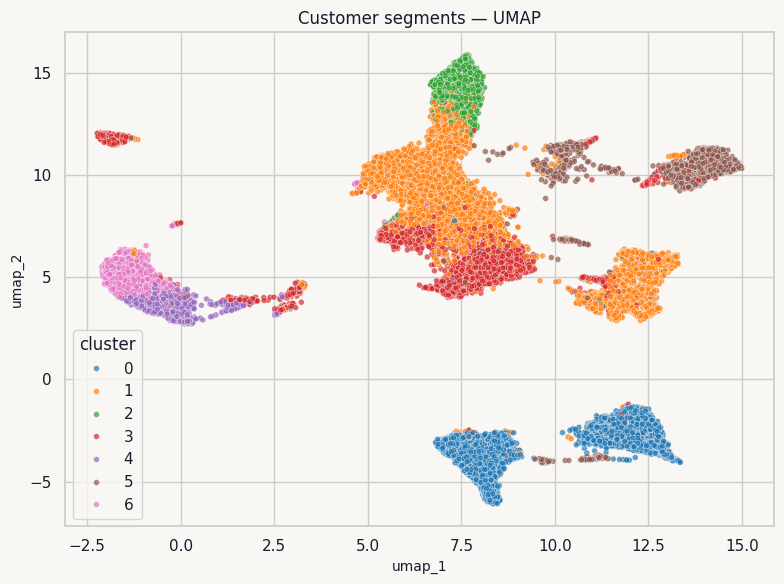

In [429]:
plot_umap_cluster_map(clean_rb, FEATURE_COLS, ward_labels_rb)

The joined clusters (1,2 and 3) have one thing in common: high loyalty card percentage, hence their overlap. Clusters 4 and 6 are both into technologies, just with slightly different personas. Lastly, cluster 3 (bargain hunters) is spread out over the map, as they are quite normal and exhibit some distinct behaviors between them, and come together with an extraordinarily percentage of products bought in promotions (0.55).

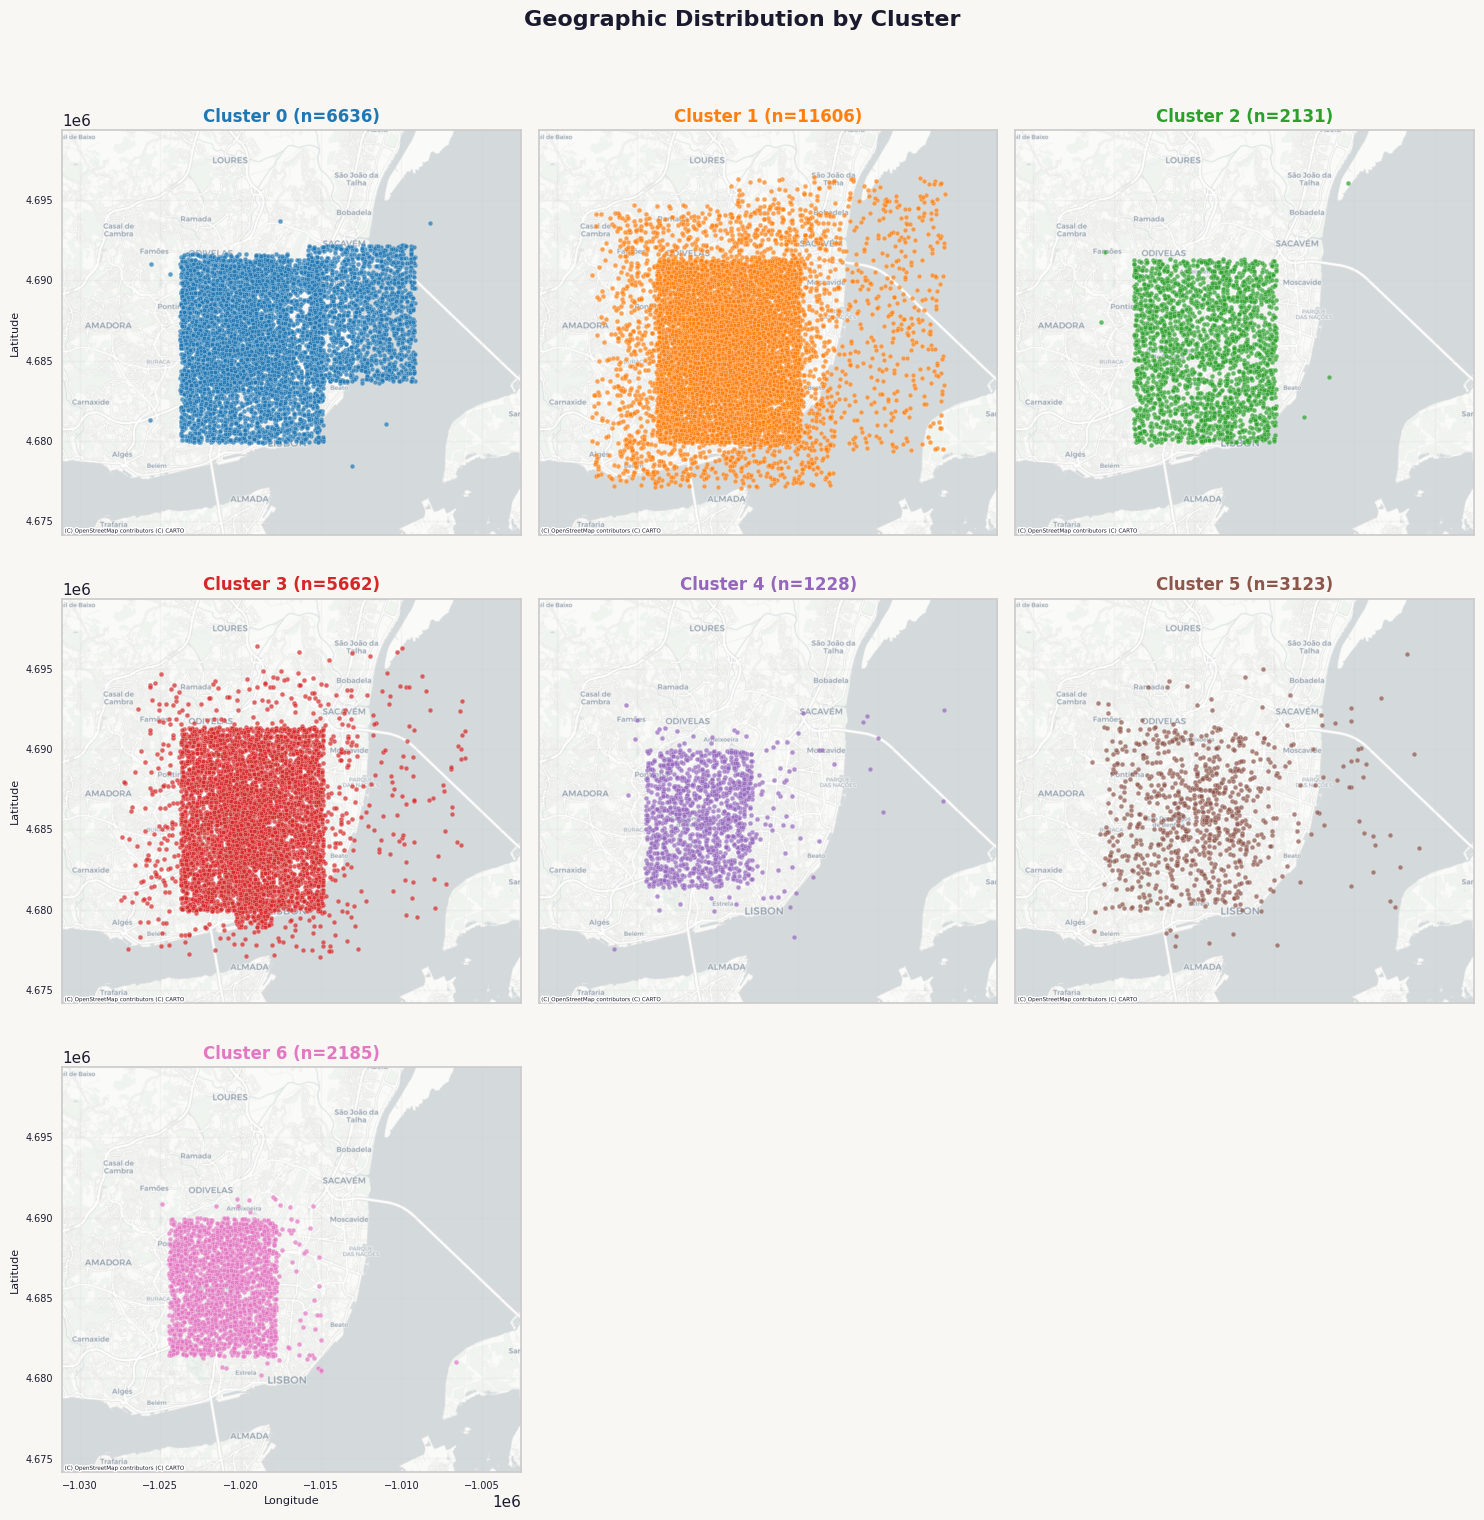

In [426]:
plot_cluster_geography(clean_rb, ward_labels_rb)

# **4. Exporting data**

In [439]:
clean_data

,customer_id,customer_name,customer_gender,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,...,share_nonalcohol_drinks,share_alcohol_drinks,share_meat,share_fish,share_hygiene,share_videogames,share_petfood,dietary_preference,final_cluster_nr,final_cluster_label
0,3,Bsc. Crystal Kitchens,female,1.0,1.0,1.0,3.0,11731.0,4553.0,12.0,...,0.017375,0.009521,0.001506,0.011458,0.029693,0.013771,0.020656,omnivore,1,Loyal core spenders
1,4,Bsc. Glenda Bauman,female,1.0,0.0,0.0,2.0,13694.0,963.0,12.0,...,0.026343,0.004695,0.002125,0.000741,0.092918,0.016458,0.032867,omnivore,0,Vegans
2,5,Msc. Antonio Campbell,male,0.0,0.0,0.0,2.0,12407.0,0.0,11.0,...,0.006496,0.007589,0.081356,0.017557,0.032607,0.006496,0.014277,omnivore,1,Loyal core spenders
3,7,John Kelling,male,0.0,0.0,2.0,1.0,7493.0,1105.0,18.0,...,0.050629,0.075776,0.065008,0.072432,0.032437,0.110754,0.012306,omnivore,4,Gamers
4,8,Arthur Dematteo,male,0.0,0.0,3.0,1.0,9187.0,10841.0,17.0,...,0.022948,0.027833,0.041400,0.039346,0.011513,0.048765,0.017095,omnivore,6,Tech enthusiasts
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32566,39996,Joshua Howard,male,0.0,0.0,2.0,1.0,475.0,13488.0,12.0,...,0.028765,0.049900,0.051205,0.057932,0.003112,0.080221,0.018373,omnivore,6,Tech enthusiasts
32567,39997,Anthony Hines,male,1.0,0.0,1.0,1.0,8430.0,14408.0,21.0,...,0.016836,0.048001,0.044817,0.020393,0.007453,0.071308,0.007690,omnivore,6,Tech enthusiasts
32568,39998,Edna Hasselman,female,1.0,1.0,0.0,4.0,8029.0,1480.0,14.0,...,0.035053,0.008302,0.021784,0.000000,0.121975,0.006315,0.018307,omnivore,0,Vegans
32569,39999,George Kramer,male,1.0,1.0,1.0,6.0,8364.0,3114.0,11.0,...,0.021979,0.047947,0.000000,0.008197,0.029740,0.000000,0.016321,omnivore,1,Loyal core spenders


In [ ]:
#clean_data.to_csv('data/ci_clustered.csv', index=False)